# Stage 3 - Data Exploration

Goal: understand the AI4I 2020 dataset before building features or a model.

We're looking for:
- What columns actually mean
- Whether `Machine failure` is rare (it usually is in real maintenance data)
- Which telemetry columns look related to failure
- Anything obviously wrong (missing values, weird ranges)

This notebook is for looking, not for logic we depend on later - see `src/data_loader.py` for that.

In [1]:

# Notebooks run with notebooks/ as the working directory, so src/ isn't
# importable by default. Add the project root to sys.path (once) so we can
# `import src...` the same way the app and tests do - see pytest.ini.
import sys
from pathlib import Path

project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_telemetry

df = load_telemetry()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Shape and types

In [2]:
print(df.shape)
df.info()

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9

## Missing values

Real telemetry usually has gaps. This dataset is simulated, so we expect none - worth confirming rather than assuming.

In [3]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## Class balance: `Machine failure`

This matters a lot. If failures are, say, 3% of rows, a model that always predicts "no failure" scores 97% accuracy while being useless - this is why Stage 5 (evaluation) won't rely on accuracy alone.

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


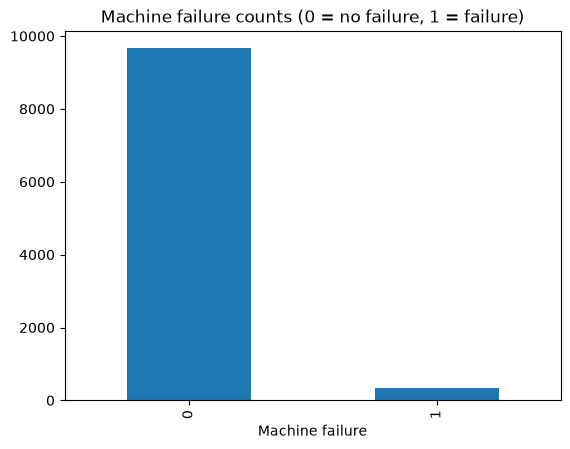

In [4]:
counts = df["Machine failure"].value_counts()
pct = df["Machine failure"].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

counts.plot(kind="bar", title="Machine failure counts (0 = no failure, 1 = failure)")
plt.show()

## Numeric feature distributions

A quick look at the telemetry readings themselves, before we relate them to failure.

In [5]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
df[numeric_cols].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


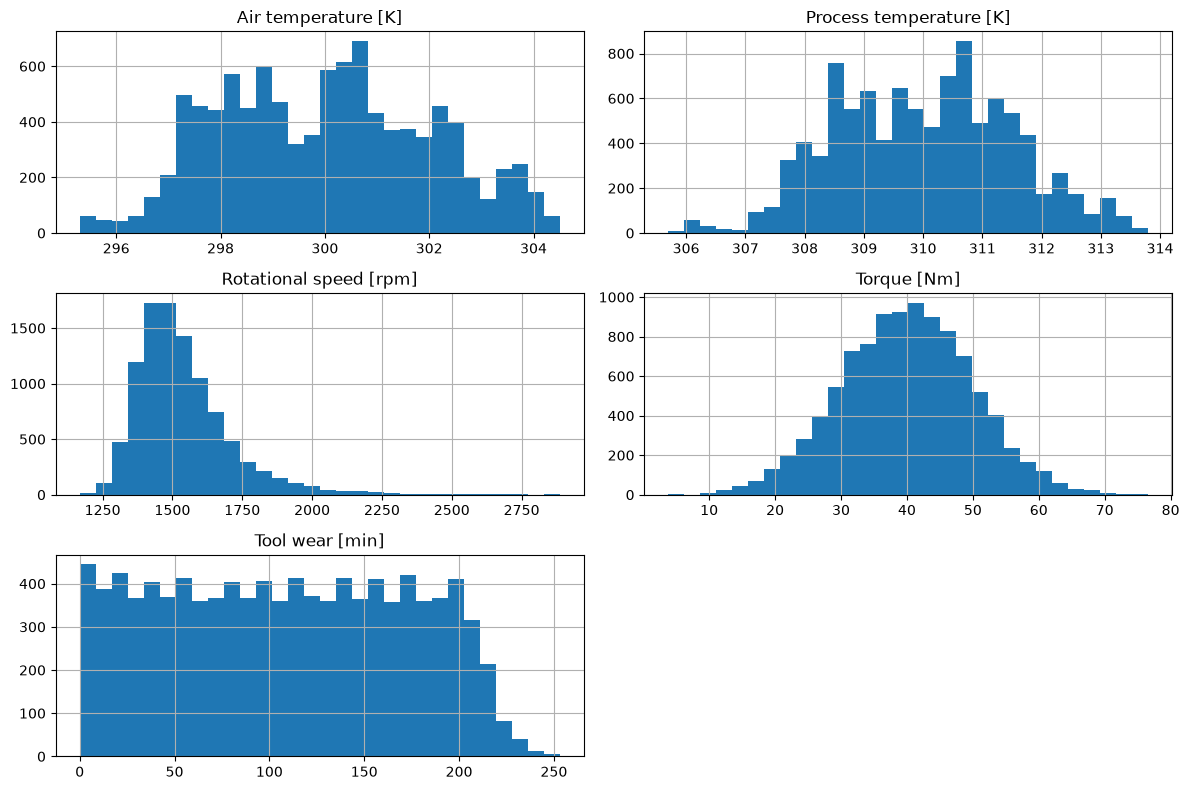

In [6]:
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

## Do these features differ between failures and non-failures?

If a column looks the same regardless of `Machine failure`, it's a weak predictor on its own.

In [7]:
df.groupby("Machine failure")[numeric_cols].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


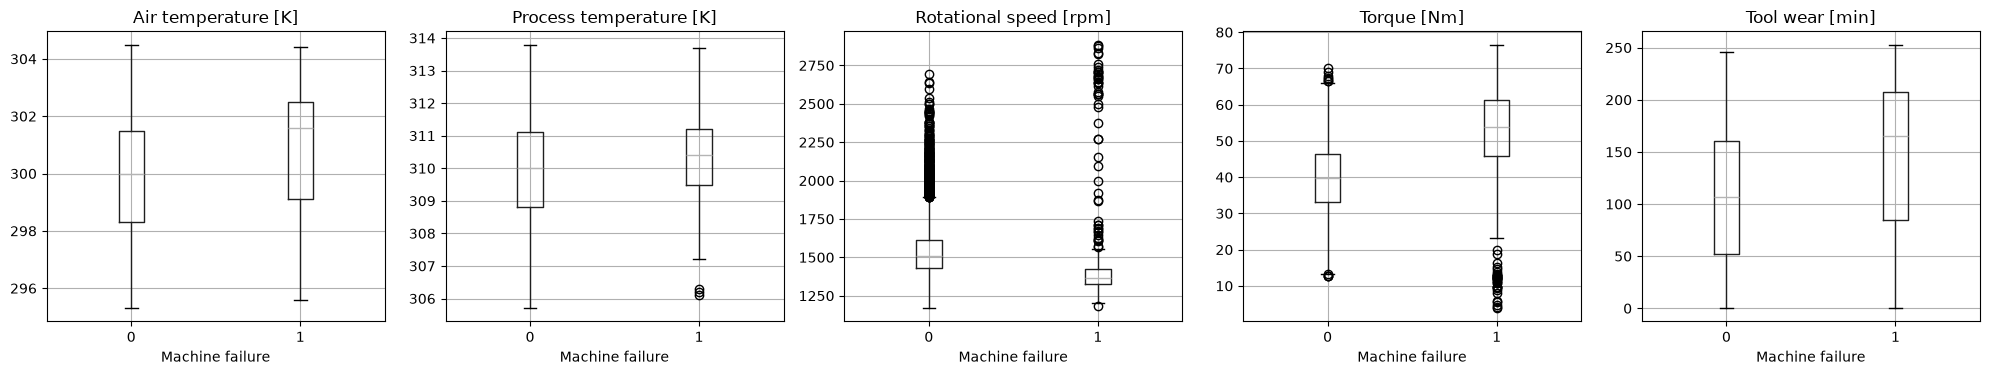

In [8]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, by="Machine failure", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

## Failure mode breakdown

The dataset also flags *which* failure mode occurred (TWF, HDF, PWF, OSF, RNF). Useful context, even though Stage 4 will start with a single binary target (`Machine failure`).

In [9]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df[failure_modes].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

## Machine type (`Type`)

L / M / H = low / medium / high quality variant. Worth checking whether failure rate differs by type.

In [10]:
df.groupby("Type")["Machine failure"].mean().sort_values(ascending=False)

Type
L    0.039167
M    0.027694
H    0.020937
Name: Machine failure, dtype: float64

## Notes / takeaways

_(Fill in after running the cells above - what stood out, what looks like a useful feature, what surprised you.)_